# Importance Sampling

In this notebook, I implement the importance sampling method for option pricing.
The content of this notebook is based on Chapter 4 of the book "Monte Carlo Methods in Financial Engineering" by Paul Glasserman.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Parameters

In [2]:
time_step = 0.01
terminal_time = 1
time_grid = np.arange(0, terminal_time + time_step, time_step)
num_steps = len(time_grid)

num_total_samples = 10000

initial_stock_price = 100
riskless = 0.03
strike_price = 105
barrier = 150

# "sigma" is a volatility term of GBM
sigma = 0.2

# "alpha" is a significance level for the confidence interval.
alpha = 0.05

theta = 2

# 2. Construction of Wiener processes

In [3]:
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z
W_tilde = W + theta * time_grid

# 3. Computation of stock prices

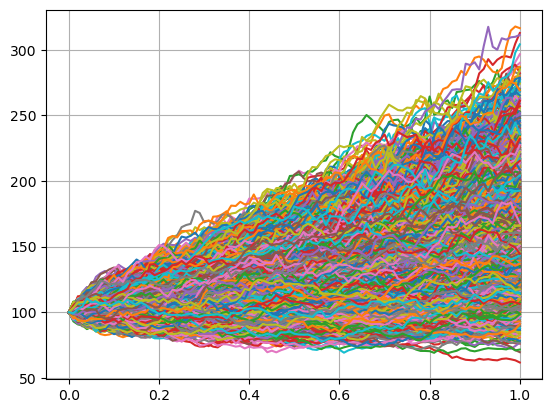

1.064835678347151


In [4]:
stock_price = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W_tilde[i][j])

for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()

likelihood_ratio = np.zeros(num_total_samples)
for i in range(num_total_samples):
    likelihood_ratio[i] = np.exp(- theta * W[i][num_steps-1] - 0.5 * theta**2 * terminal_time)

print(np.mean(likelihood_ratio))

# 4. Calculation of option payoff

In [5]:
up_and_in_call_value = np.zeros(num_total_samples)
for i in range(num_total_samples):
    if np.max(stock_price[i]) > barrier:
        up_and_in_call_value[i] = np.exp(-riskless * terminal_time) * max(stock_price[i][num_steps-1] - strike_price, 0)

Y = up_and_in_call_value * likelihood_ratio
estimated_price = np.mean(Y)
std = np.std(Y, ddof=1)

z = norm.ppf(1 - alpha/2)
conf_int_lower = estimated_price - z * std/np.sqrt(num_total_samples)
conf_int_upper = estimated_price + z * std/np.sqrt(num_total_samples)

print(f"The estimated value is {estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower:.3f},{conf_int_upper:.3f}). \n\
The length of this interval  is {conf_int_upper - conf_int_lower:.4f}")

The estimated value is 1.926, and 
95.0% confidence interval is (1.876,1.976). 
The length of this interval  is 0.1001


# 5. Comparison with plain Monte Carlo estimator

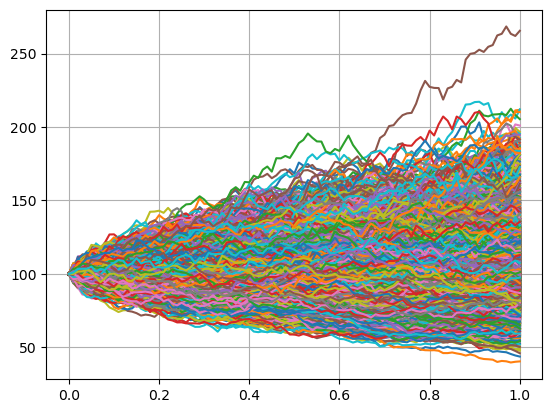

The estimated value is 2.185, and 
95.0% confidence interval is (1.977,2.393). 
The length of this interval  is 0.4161


In [6]:
stock_price = np.zeros((num_total_samples, num_steps))
W = np.zeros((num_total_samples, num_steps))
for i in range(num_total_samples):
    for j in range(num_steps-1):
        Z = np.random.normal(loc=0,scale=1)
        W[i][j+1] = W[i][j] + np.sqrt(time_grid[j+1] - time_grid[j]) * Z

for i in range(num_total_samples):
    stock_price[i][0] = initial_stock_price
    for j in range(1,num_steps):
        stock_price[i][j] = initial_stock_price * np.exp((riskless - 1/2 * sigma**2) * time_grid[j] + sigma * W[i][j])


for i in range(num_total_samples):
    plt.plot(time_grid, stock_price[i])
plt.grid(True)
plt.show()


up_and_in_call_value = np.zeros(num_total_samples)
for i in range(num_total_samples):
    if np.max(stock_price[i]) > barrier:
        up_and_in_call_value[i] = np.exp(-riskless * terminal_time) * max(stock_price[i][num_steps-1] - strike_price, 0)

estimated_price = np.mean(up_and_in_call_value)
std = np.std(up_and_in_call_value, ddof=1)

z = norm.ppf(1 - alpha/2)
conf_int_lower = estimated_price - z * std/np.sqrt(num_total_samples)
conf_int_upper = estimated_price + z * std/np.sqrt(num_total_samples)

print(f"The estimated value is {estimated_price:.3f}, and \n\
{(1-alpha)*100}% confidence interval is ({conf_int_lower:.3f},{conf_int_upper:.3f}). \n\
The length of this interval  is {conf_int_upper - conf_int_lower:.4f}")

# Reference

1. Glasserman, P. (2003) *Monte Carlo Methods in Financial Engineering*. Springer, New York.